In [1]:
import os
os.getcwd()

'c:\\Users\\Usuario\\Desktop\\Ingenieria\\Postgrado Ciencia de Datos\\Data Sience\\curso tipos de datos'

# Problemas de endcoding al cargar archivos

## *Error al decodificar bytes*

**UTF-8 es una codificación de caracteres universal que se utiliza para representar caracteres de diferentes idiomas de una manera compatible con Internet y los sistemas de computadora en general. Las siglas UTF significan Unicode Transformation Format (Formato de Transformación Unicode) y el número 8 indica que esta codificación asocia una secuencia de 1 a 4 bytes (8 a 32 bits) a cada carácter.**

*Para lo siguiente, la solución es:*

- import chardet
- with open('RUTA.csv', 'rb') as file:
    print(chardet.detect(file.read()))

- *La salida será algo como:* ***{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}***

**Lo que queda es simplemente especificar el UTF-X**

- df = pd.read_csv('RUTA.csv', encoding='UTF-16')



# Archivos excel

***Los archivos excel generalmente contienen varias hojas cuando se exportan desde ERPs, sistemas de gestión, CRM, etc. Es por esto que se utiliza el siguiente código para saber qué hojas tiene el archivo:***

- Archivo = 'RUTA'
- pd.read_excel (Archivo)
- pd.ExcelFile (Archivo).sheet_names

*Aquí la salida será una lista con los nombres de las hojas del .xlsx*
*Para seleccionar una hoja determinada el código a agregar es:*

- **pd.read_excel (Archivo, sheet_name = 'Nombre de la hoja... o número de la hoja --Parte en 0--')**

*Por otra parte para leer cierta cantidad de filas se usa el parámetro nrow = 50, por ej para leer las primeras 50 filas, y usecols = 'A:F' por ej para leer las columnas desde la A a la F...*

## Conectar GoogleColab a Google Sheets

- **Al momento de compartir el vínculo de una hoja de google sheets, el link se debe definir de la siguiente forma:**
- sheet_name = 'nombre de la hoja'
- url = f'link... al final agregarle: /gviz/tq?tqx=out:csv&sheet={sheet_name}'

datos = pd.read_csv (url)

***Probemos***...


In [2]:
import pandas as pd
sheet_name = 'emisiones_percapita'
url = f'https://docs.google.com/spreadsheets/d/11d-EA8lDL4DnDXk4sdYVGNZQbrl6jcAIxXyh4cjXTTs/gviz/tq?tqx=out:csv&sheet={sheet_name}'

data = pd.read_csv(url)
display(data.head())
display(data.tail())

,País,ISO 3166-1 alpha-3,Año,Total,Carbón,Aceite,Gas,Cemento,Quema,Otros
0,Afganistán,AFG,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afganistán,AFG,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afganistán,AFG,1752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afganistán,AFG,1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afganistán,AFG,1754,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,País,ISO 3166-1 alpha-3,Año,Total,Carbón,Aceite,Gas,Cemento,Quema,Otros
63099,Global,WLD,2017,4.749.682,1.908.857,1.610.910,940.144,198.416,51.579,39.776
63100,Global,WLD,2018,4.792.753,1.919.213,1.596.350,979.965,204.225,53.634,39.366
63101,Global,WLD,2019,4.775.633,1.896.468,1.589.920,984.878,208.309,56.569,39.490
63102,Global,WLD,2020,4.497.423,1.807.760,1.427.353,963.695,208.844,51.981,37.789
63103,Global,WLD,2021,4.693.699,1.893.923,1.496.614,1.001.585,211.472,52.663,37.443


# Archivos json

## *Carga de datos y errores*

Muchas veces los archivos json contienen listas de diccionarios en una variable determinada, para resolver este problema se realiza lo siguiente:

---
*Se carga el archivo*
- data = pd.read_json ('archivo.json')
- display (data.head())

*En el caso anterior, por ejemplo en la variable 3 estará el error al visualizar el dataframe*
- data2 = pd.json_normalize (data['variable con el error'])

**Ejecutando el código anterior se creará un nuevo dataframe aparte del primero (data) cargado**

---
nota: sólo funciona crear este nuevo dataframe con la variable que da error cuando esta variable contiene una **LISTA** de 2 o más diccionarios

## *Otros errores...*

**En caso que aparezcan otros errores por los diccionarios que a veces se encuentran o no dentro de listas, se realiza lo siguiente:**

---

import pandas as pd

import json

---
#Leyendo el archivo json usando el módulo Python JSON
with open('pacientes_2.json','r') as f:
    datos = json.loads(f.read())

***Además, es importante saber que el parámetro "meta=['variable1', 'variable2',]" sirve para incluir las variables (sin error) del primer dataframe y "concatenarlas" con el dataframe nuevo que se contenía en uno o más diccionarios.***

#Normalizando los datos con los parámetros record_path y meta
pd.json_normalize(datos, record_path='Pacientes', meta=['Investigación', 'Año'])

---

## Ejemplo práctico

---
**Tenemos la siguiente situación-problema:**

“Una empresa de alimentos saludables tiene problemas con la popularidad de sus productos. A pesar de ofrecer opciones saludables, muchos clientes se muestran reacios a comprar los productos debido a la falta de información sobre los valores nutricionales de las frutas que se utilizan en la producción de alimentos”.

Ante esta situación podemos acceder a una API llamada Fruitvice para recopilar información detallada sobre los valores nutricionales de las frutas que se utilizan en los productos. Con esta información, la empresa podrá actualizar sus empaques y materiales de marketing para resaltar los valores nutricionales de las frutas y así atraer más clientes que buscan opciones saludables. Además, la empresa puede utilizar la información para desarrollar nuevos productos que satisfagan aún más las necesidades nutricionales de su clientela.

---
Para lo anterior, usamos una biblioteca llamada request para acceder a las API.
- import request
- import json
- datos_frutas = requests.get('https://fruityvice.com/api/fruit/all')
- resultado = json.loads(datos_frutas.text) #text devuelve el contenido de la respuesta

**Visualizar DataFrame:** pd.DataFrame(resultado)

In [3]:
import pandas as pd
import requests
import json

In [4]:
datos_frutas = requests.get ('https://fruityvice.com/api/fruit/all')
data = json.loads (datos_frutas.text)

display(pd.DataFrame (data))


,name,id,family,order,genus,nutritions
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,"{'calories': 81, 'fat': 0.0, 'sugar': 18.0, 'c..."
1,Strawberry,3,Rosaceae,Rosales,Fragaria,"{'calories': 29, 'fat': 0.4, 'sugar': 5.4, 'ca..."
2,Banana,1,Musaceae,Zingiberales,Musa,"{'calories': 96, 'fat': 0.2, 'sugar': 17.2, 'c..."
3,Tomato,5,Solanaceae,Solanales,Solanum,"{'calories': 74, 'fat': 0.2, 'sugar': 2.6, 'ca..."
4,Pear,4,Rosaceae,Rosales,Pyrus,"{'calories': 57, 'fat': 0.1, 'sugar': 10.0, 'c..."
5,Durian,60,Malvaceae,Malvales,Durio,"{'calories': 147, 'fat': 5.3, 'sugar': 6.75, '..."
6,Blackberry,64,Rosaceae,Rosales,Rubus,"{'calories': 40, 'fat': 0.4, 'sugar': 4.5, 'ca..."
7,Lingonberry,65,Ericaceae,Ericales,Vaccinium,"{'calories': 50, 'fat': 0.34, 'sugar': 5.74, '..."
8,Kiwi,66,Actinidiaceae,Struthioniformes,Apteryx,"{'calories': 61, 'fat': 0.5, 'sugar': 9.0, 'ca..."
9,Lychee,67,Sapindaceae,Sapindales,Litchi,"{'calories': 66, 'fat': 0.44, 'sugar': 15.0, '..."


In [5]:
df = pd.json_normalize (data, sep= '_')
df.head()

,name,id,family,order,genus,nutritions_calories,nutritions_fat,nutritions_sugar,nutritions_carbohydrates,nutritions_protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.0,18.0,18.0,0.0
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.4,5.4,5.5,0.8
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.2,17.2,22.0,1.0
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.2,2.6,3.9,0.9
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.1,10.0,15.0,0.4


In [6]:
df.to_json ('propiedades_frutas.json', index = False)
df.to_csv ('propiedades_frutas2.csv', index = False)

### Tipos de formato

---
***Si alguna variable contiene simplemente diccionarios anidados sin listas, usar:***
- pd.json_normalize (data)

---
***Si alguna variable contiene una lista de diccionarios anidados, usar:***
- pd.json_normalize (data, record_path = 'variable con lista', meta = data.columns[:4].tolist())
- Lo último es para mantener las primeras 4 columnas por ejemplo, en caso de que estas estén limpias

# Archivos HTML

## *Carga de datos*

*El siguiente ejercicio que se verá, trata de cómo se podrá copiar una tabla en alguna página web hacia python. Para este ejercicio, se buscará un "recomendador de películas" por lo que en el siguiente link se puede ver una mini tabla donde aparecen algunas peliculas recomendadas según autor, año, etc...*

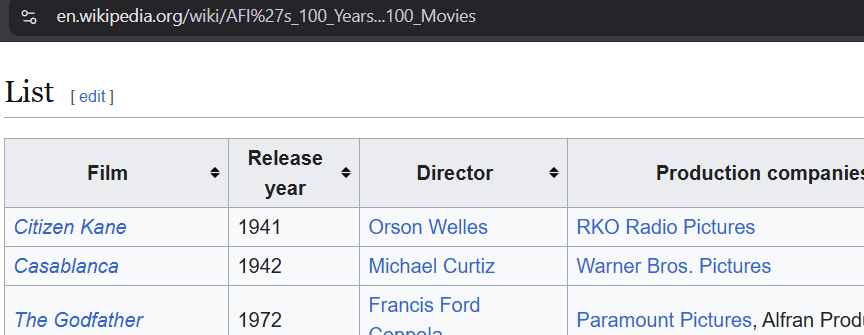

Se puede visualizar que existe una tabla... si vamos a inspeccionar la web (con fn+f12) y apretamos ctrl+F (find) se puede escribir <table> y aparecerá/n la/s tabla/s disponible/s

La web es la siguiente: [Web 100 películas](https://es.wikipedia.org/wiki/Anexo:AFI%27s_100_a%C3%B1os..._100_pel%C3%ADculas)


In [25]:
datos_html = pd.read_html('web 100 peliculas.html')[0]

In [26]:
len(datos_html)

100

In [27]:
datos_html.head()

,Puesto,Título original,Título(s) en español,Año de lanzamiento,Director,Estudio
0,1,Citizen Kane,"El ciudadano (AR, UY) / Ciudadano Kane (ES, HA)",1941,Orson Welles,RKO Radio Pictures United Artists (1971-1986) ...
1,2,Casablanca,Casablanca,1942,Michael Curtiz,Warner Bros.-First National Associated Artists...
2,3,The Godfather,El padrino,1972,Francis Ford Coppola,Paramount Pictures
3,4,Gone with the wind,Lo que el viento se llevó,1939,Victor Fleming George Cukor (no acreditado) Sa...,Metro-Goldwyn-Mayer Turner Entertainment (1986...
4,5,Lawrence of Arabia,Lawrence de Arabia,1962,David Lean,Columbia Pictures


In [28]:
datos_html.to_html('top_peliculas.html', index= False)

***Para abrir el archivo anterior (top_peliculas) se debe importar igualmente que lo anterior con pd.read_html y al final agregar [0]...***